# How to Achieve Success by Streaming on Twitch​

By: Annette Martin​, Semen Petrov​, Kunanon Chaojaroenrat​, Ismail Cem Bayramoglu​

## Define success​:

* Number of subscribers​
* Number of followers​
* Earnings​
* Monthly viewers​
* Viewer watch time​
* Sponsors​
* Growth rate​

**Streamer:** Make a decision about streaming content and schedule.​

**Administrator:** analyze past performance and forecast about some game that can increase average viewers. Then recommend the option to the streamer.​

**Moderator:** Introduce new streamers, welcome raiders, ban certain people or languages, and increasing the engagement​

**Sponsor:** Decide which streamer to support based on viewers engagement and growth rate​

# Kaggle data

In [12]:
# Imports all in one location

import os
import pandas as pd
import kagglehub
import requests

In [13]:
# Helper function
def load_first_data_file(folder_path):
    """
    Load the first CSV, TXT, or XLSX file in the given folder as a Pandas DataFrame.
    """
    for file in os.listdir(folder_path):
        full_path = os.path.join(folder_path, file)

        if file.lower().endswith(".csv"):
            # Try UTF-8 first, then fall back to other encodings
            try:
                return pd.read_csv(full_path)
            except UnicodeDecodeError:
                try:
                    return pd.read_csv(full_path, encoding='latin-1')
                except:
                    return pd.read_csv(full_path, encoding='cp1252')

        elif file.lower().endswith(".txt"):
            try:
                return pd.read_csv(full_path, sep="\t")
            except UnicodeDecodeError:
                try:
                    return pd.read_csv(full_path, sep="\t", encoding='latin-1')
                except:
                    return pd.read_csv(full_path, sep="\t", encoding='cp1252')

        elif file.lower().endswith(".xlsx"):
            return pd.read_excel(full_path)

    raise FileNotFoundError(f"No supported data files found in {folder_path}")

In [14]:
datasets = {
    "streamers": "aayushmishra1512/twitchdata", # https://www.kaggle.com/datasets/aayushmishra1512/twitchdata
    "top_games": "rankirsh/evolution-of-top-games-on-twitch", # https://www.kaggle.com/datasets/rankirsh/evolution-of-top-games-on-twitch
}

dfs = {}

for name, kaggle_path in datasets.items():
    folder_path = kagglehub.dataset_download(kaggle_path)
    dfs[name] = load_first_data_file(folder_path)

    print(f"\n{name.upper()} preview:")
    display(dfs[name].head())

Using Colab cache for faster access to the 'twitchdata' dataset.

STREAMERS preview:


,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English


Using Colab cache for faster access to the 'evolution-of-top-games-on-twitch' dataset.

TOP_GAMES preview:


,year,Month,Hours_watched,Avg_viewers,Peak_viewers,Streams,Avg_channels,Games_streamed,Viewer_ratio
0,2016,1,480241904,646355,1275257,7701675,20076,12149,29.08
1,2016,2,441859897,635769,1308032,7038520,20427,12134,28.98
2,2016,3,490669308,660389,1591551,7390957,20271,12234,28.92
3,2016,4,377975447,525696,1775120,6869719,16791,12282,28.80
4,2016,5,449836631,605432,1438962,7535519,19394,12424,28.85


In [15]:
display(dfs["streamers"].tail())
display(dfs["top_games"].tail())

,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
995,LITkillah,122524635,13560,21359,9104,601927,562691,2162107,True,False,Spanish
996,빅헤드 (bighead033),122523705,153000,3940,793,213212,52289,4399897,True,False,Korean
997,마스카 (newmasca),122452320,217410,6431,567,109068,-4942,3417970,True,False,Korean
998,AndyMilonakis,122311065,104745,10543,1153,547446,109111,3926918,True,False,English
999,Remx,122192850,99180,13788,1205,178553,59432,2049420,True,False,French


,year,Month,Hours_watched,Avg_viewers,Peak_viewers,Streams,Avg_channels,Games_streamed,Viewer_ratio
100,2024,5,1727139900,2324548,4032587,22686570,91550,46363,25.90
101,2024,6,1617653502,2249865,4560410,22209935,92133,46752,24.78
102,2024,7,1660370134,2234683,6872963,23309553,93039,46904,24.24
103,2024,8,1711442710,2303422,4159346,23399616,93682,46965,25.14
104,2024,9,1698990192,2362990,4343770,21730541,90841,45635,26.46


# Moving Kaggle Data to BigQuery

In [16]:
# This has already been uploaded, no need to do it again
'''
from google.colab import auth
from google.cloud import bigquery

print("UPLOAD DATAFRAMES TO BIGQUERY")

# Check what dataframes are available
print(f"\nFound {len(dfs)} dataframe(s) to upload:")
for name, df in dfs.items():
    print(f"  - {name}: {df.shape[0]} rows × {df.shape[1]} columns")

# AUTHENTICATE AND SETUP
print("BigQuery Setup")

# Authenticate
auth.authenticate_user()
print("✓ Authenticated with Google Cloud")

# Get BigQuery details
project_id = input("\nEnter your Google Cloud Project ID: ").strip()
dataset_name = input("Enter BigQuery dataset name (e.g., 'twitch_data'): ").strip().lower().replace(' ', '_').replace('-', '_')

# UPLOAD TO BIGQUERY
try:
    # Initialize BigQuery client
    client = bigquery.Client(project=project_id)

    # Create dataset if it doesn't exist
    dataset_id = f"{project_id}.{dataset_name}"
    dataset = bigquery.Dataset(dataset_id)
    dataset.location = "US"

    try:
        dataset = client.create_dataset(dataset, exists_ok=True)
        print(f"\n✓ Dataset '{dataset_name}' ready in project '{project_id}'")
    except Exception as e:
        print(f"\n⚠ Dataset creation note: {e}")
        print("Continuing with upload...")

    print("Uploading tables to BigQuery...")

    successful_uploads = 0
    failed_uploads = []

    for table_name, df in dfs.items():
        try:
            # Clean table name (BigQuery requirements)
            clean_table_name = table_name.lower().replace(' ', '_').replace('-', '_')
            table_id = f"{dataset_id}.{clean_table_name}"

            # Clean column names (BigQuery requirements)
            # Remove special characters and replace with underscores
            df_clean = df.copy()
            df_clean.columns = [
                col.replace('(', '_')
                   .replace(')', '_')
                   .replace(' ', '_')
                   .replace('-', '_')
                   .replace('.', '_')
                   .replace('/', '_')
                   .replace('\\', '_')
                   .replace(',', '_')
                   .replace(';', '_')
                   .replace(':', '_')
                   .replace('!', '_')
                   .replace('?', '_')
                   .replace('#', '_')
                   .replace('&', '_')
                   .replace('%', '_')
                   .replace('*', '_')
                   .replace('+', '_')
                   .replace('=', '_')
                   .replace('<', '_')
                   .replace('>', '_')
                   .replace('[', '_')
                   .replace(']', '_')
                   .replace('{', '_')
                   .replace('}', '_')
                   .replace('|', '_')
                   .replace('~', '_')
                   .replace('`', '_')
                   .replace('"', '_')
                   .replace("'", '_')
                   .strip('_')  # Remove leading/trailing underscores
                for col in df.columns
            ]

            # Remove consecutive underscores
            df_clean.columns = [
                '_'.join(filter(None, col.split('_')))
                for col in df_clean.columns
            ]

            # Configure the upload
            job_config = bigquery.LoadJobConfig(
                write_disposition="WRITE_TRUNCATE",  # Overwrite if exists
                autodetect=True  # Auto-detect schema
            )

            # Upload the dataframe
            print(f"Uploading {clean_table_name}...", end=" ")
            job = client.load_table_from_dataframe(
                df_clean, table_id, job_config=job_config
            )
            job.result()  # Wait for completion

            print(f"✓ ({df.shape[0]} rows)")
            successful_uploads += 1

        except Exception as e:
            print(f"✗")
            print(f"  Error: {e}")
            failed_uploads.append(table_name)

    print(f"\n✓ Successfully uploaded {successful_uploads}/{len(dfs)} table(s)")

    if failed_uploads:
        print(f"\n⚠ Failed uploads: {', '.join(failed_uploads)}")

    print(f"\nYour data is now in BigQuery:")
    print(f"  Project: {project_id}")
    print(f"  Dataset: {dataset_name}")
    print(f"  Tables: {', '.join([name for name in dfs.keys()])}")
    print(f"\nView your data at:")
    print(f"  https://console.cloud.google.com/bigquery?project={project_id}")
    print(f"\nExample queries:")
    for name in dfs.keys():
        clean_name = name.lower().replace(' ', '_').replace('-', '_')
        print(f"  SELECT * FROM `{project_id}.{dataset_name}.{clean_name}` LIMIT 10;")
    print("=" * 80)

except Exception as e:
    print(f"\n✗ Error uploading to BigQuery: {e}")
    print("\nTroubleshooting:")
    print("  1. Verify your project exists at: https://console.cloud.google.com/")
    print("  2. Enable BigQuery API: https://console.cloud.google.com/apis/library/bigquery.googleapis.com")
    print("  3. Check your Project ID is correct (use hyphens, not underscores)")
    print(f"  4. Current Project ID attempt: '{project_id}'")
    '''

'\nfrom google.colab import auth\nfrom google.cloud import bigquery\n\nprint("UPLOAD DATAFRAMES TO BIGQUERY")\n\n# Check what dataframes are available\nprint(f"\nFound {len(dfs)} dataframe(s) to upload:")\nfor name, df in dfs.items():\n    print(f"  - {name}: {df.shape[0]} rows × {df.shape[1]} columns")\n\n# AUTHENTICATE AND SETUP\nprint("BigQuery Setup")\n\n# Authenticate\nauth.authenticate_user()\nprint("✓ Authenticated with Google Cloud")\n\n# Get BigQuery details\nproject_id = input("\nEnter your Google Cloud Project ID: ").strip()\ndataset_name = input("Enter BigQuery dataset name (e.g., \'twitch_data\'): ").strip().lower().replace(\' \', \'_\').replace(\'-\', \'_\')\n\n# UPLOAD TO BIGQUERY\ntry:\n    # Initialize BigQuery client\n    client = bigquery.Client(project=project_id)\n\n    # Create dataset if it doesn\'t exist\n    dataset_id = f"{project_id}.{dataset_name}"\n    dataset = bigquery.Dataset(dataset_id)\n    dataset.location = "US"\n\n    try:\n        dataset = client.

# Twitch direct information

In [17]:
import requests
import time
import pandas as pd
import pandas as pd
from tqdm import tqdm

In [18]:
# Your Twitch App credentials
TWITCH_CLIENT_ID = "bzzl4wywab65nscubsjrpfy22vlsbs"
TWITCH_CLIENT_SECRET = "jl3yczpr3j5qrs1qdsfjgfx6fgx4fx"

# Get a new App Access Token
def get_app_token():
    url = "https://id.twitch.tv/oauth2/token"
    data = {
        "client_id": TWITCH_CLIENT_ID,
        "client_secret": TWITCH_CLIENT_SECRET,
        "grant_type": "client_credentials"
    }
    resp = requests.post(url, data=data)
    resp.raise_for_status()
    token_info = resp.json()
    return token_info["access_token"], time.time() + token_info["expires_in"] - 60  # expire slightly earlier

# Global token storage
TOKEN, TOKEN_EXPIRY = get_app_token()

def ensure_token():
    global TOKEN, TOKEN_EXPIRY
    if time.time() >= TOKEN_EXPIRY:
        TOKEN, TOKEN_EXPIRY = get_app_token()

# Fetch live streams
def get_streams(first=100, after=None):
    ensure_token()
    url = "https://api.twitch.tv/helix/streams"
    headers = {
        "Client-ID": TWITCH_CLIENT_ID,
        "Authorization": f"Bearer {TOKEN}"
    }
    params = {"first": first}
    if after:
        params["after"] = after
    resp = requests.get(url, headers=headers, params=params)
    resp.raise_for_status()
    return resp.json()

# Get a large sample of live streamers
def get_live_streamers_sample(max_streamers=2000):
    streamers = set()
    cursor = None
    while len(streamers) < max_streamers:
        resp = get_streams(first=100, after=cursor)
        for s in resp['data']:
            streamers.add(s['user_login'])
        cursor = resp.get('pagination', {}).get('cursor')
        if not cursor:
            break
    return streamers

# Example usage
candidate_streamers = get_live_streamers_sample(max_streamers=2000)
print("Number of live streamers sampled:", len(candidate_streamers))

Number of live streamers sampled: 2000


In [19]:
# Sample of live streamers
candidate_streamers = get_live_streamers_sample(max_streamers=500)  # adjust size as needed

# All streamers
rows = []

for username in tqdm(candidate_streamers, desc="Processing streamers"):
    try:
        row = build_quality_features(username)
        if row:
            rows.append(row)
    except Exception as e:
        print(f"⚠️ Skipping {username} due to error: {e}")

# DataFrame
df_streamers = pd.DataFrame(rows)

print(f"Built features for {len(df_streamers)} streamers")
display(df_streamers.head())

Processing streamers: 100%|██████████| 500/500 [00:00<00:00, 147416.84it/s]

⚠️ Skipping kadditv due to error: name 'build_quality_features' is not defined
⚠️ Skipping vanotica_ due to error: name 'build_quality_features' is not defined
⚠️ Skipping moosebrother due to error: name 'build_quality_features' is not defined
⚠️ Skipping ilgattosultubo due to error: name 'build_quality_features' is not defined
⚠️ Skipping berlu due to error: name 'build_quality_features' is not defined
⚠️ Skipping minuself due to error: name 'build_quality_features' is not defined
⚠️ Skipping koma due to error: name 'build_quality_features' is not defined
⚠️ Skipping cutedog_ due to error: name 'build_quality_features' is not defined
⚠️ Skipping asiagodtonegg3be0 due to error: name 'build_quality_features' is not defined
⚠️ Skipping yann due to error: name 'build_quality_features' is not defined
⚠️ Skipping sonrazh due to error: name 'build_quality_features' is not defined
⚠️ Skipping ir1napart due to error: name 'build_quality_features' is not defined
⚠️ Skipping meloonie due to erro

""


In [20]:
len(df_streamers)
df_streamers.head(10)
df_streamers.tail()

""


In [21]:
df_streamers.to_csv("twitch_streamers_features.csv", index=False)

In [22]:
# Load existing CSV
try:
    df_existing = pd.read_csv("twitch_streamers_features.csv")
except FileNotFoundError:
    df_existing = pd.DataFrame()  # if it doesn't exist yet

# Combine with new DataFrame
df_combined = pd.concat([df_existing, df_streamers], ignore_index=True)

# Remove duplicates based on username
df_combined = df_combined.drop_duplicates(subset="username")

# Save back to CSV
df_combined.to_csv("twitch_streamers_features.csv", index=False)
df_streamers.to_csv(f"twitch_streamers_features_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv", index=False)

EmptyDataError: No columns to parse from file

# Analysis

In [23]:
dic = {}

for count, gamerank in enumerate(dfs['top_games']['Rank']):
  if gamerank <= 10:
    try:
      dic[dfs['top_games']['Game'][count]] += 1
    except:
      dic[dfs['top_games']['Game'][count]] = 1

for i in dict(dic):
  if dic[i] < 10:
    dic.pop(i)
print(dic)

KeyError: 'Rank'

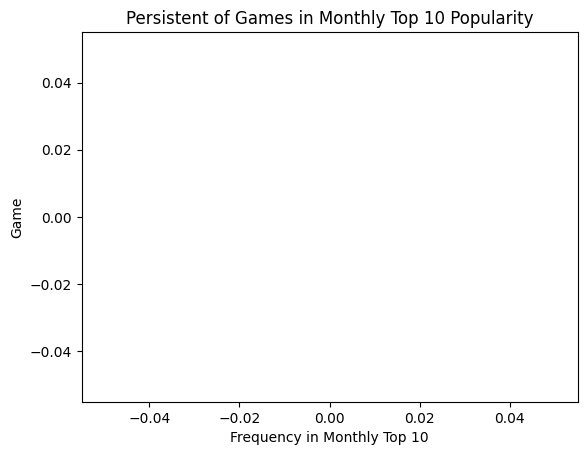

In [24]:
import matplotlib.pyplot as plt

y= dic.keys()
x= dic.values()

plt.barh(y, x)
plt.ylabel("Game")
plt.xlabel("Frequency in Monthly Top 10")
plt.title("Persistent of Games in Monthly Top 10 Popularity")
plt.show()

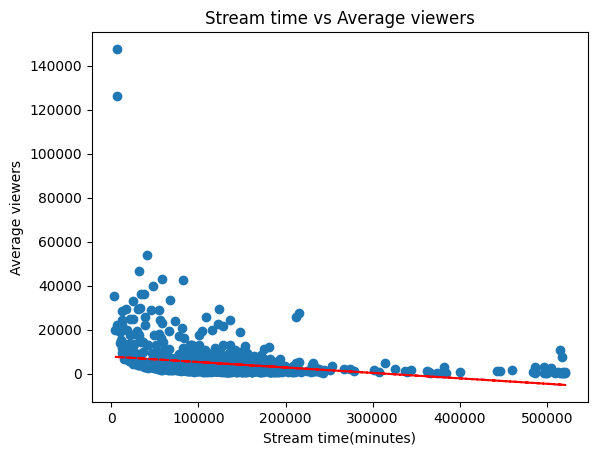

In [25]:
import matplotlib.pyplot as plt
import numpy as np

x = dfs['streamers']['Stream time(minutes)']
y = dfs['streamers']['Average viewers']

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y)
plt.plot(x, p(x), "r--")
plt.title("Stream time vs Average viewers")
plt.xlabel("Stream time(minutes)")
plt.ylabel("Average viewers")
plt.show()